In [1]:
import json
import os
import subprocess
from datetime import datetime, timezone
from pathlib import Path

try:
    from dotenv import load_dotenv, find_dotenv
    load_dotenv(find_dotenv("../configs/.env", raise_error_if_not_found=False), override=False)
except ImportError:
    # python-dotenv optional; notebook still works with shell-exported vars.
    pass

import matplotlib.pyplot as plt
import mlflow
import mlflow.xgboost
import numpy as np
import pandas as pd
import seaborn as sns
import shap
import xgboost as xgb
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

# --- Config ---
FEATURES_DIR = Path("../ml/data/features")
MODELS_DIR = Path("../ml/models")
LOGS_DIR = Path("../logs/mlflow")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# --- Load feature-engineered splits ---
train = pd.read_parquet(FEATURES_DIR / "train_features.parquet")
val = pd.read_parquet(FEATURES_DIR / "val_features.parquet")
test = pd.read_parquet(FEATURES_DIR / "test_features.parquet")

print(f"Train: {len(train):,} rows | Fraud: {train['isFraud'].sum():,} ({train['isFraud'].mean()*100:.3f}%)")
print(f"Val:   {len(val):,} rows | Fraud: {val['isFraud'].sum():,} ({val['isFraud'].mean()*100:.3f}%)")
print(f"Test:  {len(test):,} rows | Fraud: {test['isFraud'].sum():,} ({test['isFraud'].mean()*100:.3f}%)")
print(f"\nTotal columns: {len(train.columns)}")

/Users/ngocduy/PROJECTS/smart-banking-system/ml/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Train: 2,701,957 rows | Fraud: 5,993 (0.222%)
Val:   33,583 rows | Fraud: 792 (2.358%)
Test:  34,098 rows | Fraud: 776 (2.276%)

Total columns: 28


## Model Training Plan

1. **Define feature set** — exclude identifiers, raw balances, and the target
2. **Handle class imbalance** — `scale_pos_weight = neg/pos` ratio
3. **Train XGBoost** with early stopping on validation set
4. **Evaluate** — AUC, PR-AUC, precision/recall at contract thresholds (0.5, 0.8)
5. **Threshold tuning** — find optimal threshold for F1 or business metric
6. **SHAP analysis** — global feature importance + per-decision explainability
7. **Baseline comparison** — our model vs PaySim's built-in `isFlaggedFraud` rule
8. **Export** — save as ONNX for deployment in `ml/app/`

### 1. Define Feature Set

We exclude:
- **Identifiers**: `nameOrig`, `nameDest` (strings, not features)
- **Raw balances**: `oldbalanceOrg`, `newbalanceOrig`, `oldbalanceDest`, `newbalanceDest` (not used directly — see below)
- **Balance leak features** (`orig_error`, `dest_error`, `has_orig_error`, `has_dest_error`):
  - PaySim's fraud-generation rules enforce the balance invariants
    (`oldbalanceOrg - newbalanceOrig == amount`) deterministically, so any
    tree that splits on these achieves AUC ≈ 1.0 on PaySim without learning
    anything generalizable. See notebook 03 §1 caveats.
  - They require post-state balances (`newbalanceOrig`, `newbalanceDest`)
    which are not in the `ScoreRequest` schema — see
    `docs/ml-service-contract.md` §2. Computing them at inference time
    needs extra Postgres lookups.
  - **Dropped from v1.** Phase 2 may revisit if we add a serving-side
    pre-fetch step (subject to the <250ms latency budget).
- **Redundant**: `type` (encoded as `is_transfer`), `amount` (encoded as `amount_log` + `amount_zscore`)
- **Target**: `isFraud`
- **Baseline**: `isFlaggedFraud` (kept for comparison, not training)
- **Metadata**: `step` (encoded as time features)

In [2]:
DROP_COLS = [
    "nameOrig", "nameDest",              # identifiers
    "oldbalanceOrg", "newbalanceOrg",   # raw balance columns
    "oldbalanceDest", "newbalanceDest",
    # --- Dropped in v1: simulator-leak + inference-gap features ---
    # See notebook 03 §1 caveats. These four features give AUC≈1.0 on
    # PaySim because the simulator enforces them, but they need
    # newbalanceOrig / newbalanceDest which aren't in the ScoreRequest
    # schema. Phase 2 may revisit if serving-side pre-fetch is added.
    "orig_error",
    "dest_error",
    "has_orig_error",
    "has_dest_error",
    "type",                               # encoded as is_transfer
    "amount",                             # encoded as amount_log + amount_zscore
    "step",                               # encoded as time features
    "isFraud",                            # target
    "isFlaggedFraud",                     # baseline (not a feature)
]

feature_cols = [c for c in train.columns if c not in DROP_COLS]

X_train = train[feature_cols]
y_train = train["isFraud"]
X_val = val[feature_cols]
y_val = val["isFraud"]
X_test = test[feature_cols]
y_test = test["isFraud"]

print(f"Feature columns ({len(feature_cols)}):")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {col}")

print(f"\nX_train: {X_train.shape} | y_train fraud: {y_train.sum():,}")
print(f"X_val:   {X_val.shape} | y_val fraud:   {y_val.sum():,}")
print(f"X_test:  {X_test.shape} | y_test fraud:  {y_test.sum():,}")

Feature columns (14):
   1. newbalanceOrig
   2. is_transfer
   3. amount_log
   4. balance_emptying_ratio
   5. sin_hour
   6. cos_hour
   7. sin_dow
   8. cos_dow
   9. velocity_1h
  10. velocity_24h
  11. velocity_3d
  12. amount_zscore
  13. new_recipient_flag
  14. time_since_last_txn

X_train: (2701957, 14) | y_train fraud: 5,993
X_val:   (33583, 14) | y_val fraud:   792
X_test:  (34098, 14) | y_test fraud:  776


### 2. Handle Class Imbalance

PaySim fraud rate is ~0.13%. Without adjustment, the model predicts "not fraud" for everything and gets 99.87% accuracy — useless.

XGBoost's `scale_pos_weight` reweights the positive class:

$$\text{scale\_pos\_weight} = \frac{\text{count(neg)}}{\text{count(pos)}}$$

This makes each fraud example count as much as ~770 legitimate examples during training.

In [3]:
# ============================================================
# 2. Compute scale_pos_weight
# ============================================================

neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count

print(f"Negative (legit): {neg_count:,}")
print(f"Positive (fraud): {pos_count:,}")
print(f"scale_pos_weight: {scale_pos_weight:.1f}")

Negative (legit): 2,695,964
Positive (fraud): 5,993
scale_pos_weight: 449.9


### 3. Train XGBoost

Key hyperparameters:
- `scale_pos_weight` — handles imbalance
- `max_depth=6` — deep enough to capture interactions, shallow enough to avoid overfitting
- `learning_rate=0.05` — conservative, works well with early stopping
- `eval_metric='aucpr'` — PR-AUC is more informative than ROC-AUC for imbalanced data
- Early stopping after 50 rounds of no improvement on validation set

In [4]:
model = xgb.XGBClassifier(
    n_estimators=2000,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="aucpr",
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=25,  # log every 25 iterations (was 100 — too sparse for early-stopping runs)
)

print(f"\nBest iteration: {model.best_iteration}")
print(f"Best validation AUC-PR: {model.best_score:.4f}")

[0]	validation_0-aucpr:0.97613
[25]	validation_0-aucpr:0.98355
[50]	validation_0-aucpr:0.98347
[75]	validation_0-aucpr:0.98338
[77]	validation_0-aucpr:0.98341

Best iteration: 27
Best validation AUC-PR: 0.9841


### 4. Evaluate — Test Set

We evaluate on the held-out test set (last 10% of steps — never seen during training or early stopping).

=== Test Set Metrics ===
ROC-AUC:  0.9997
PR-AUC:   0.9850

Threshold 0.3: Precision=0.8479 | Recall=0.9987 | F1=0.9172 | Flagged=914 (2.68%)
Threshold 0.5: Precision=0.9095 | Recall=0.9974 | F1=0.9514 | Flagged=851 (2.50%)
Threshold 0.8: Precision=0.9642 | Recall=0.9021 | F1=0.9321 | Flagged=726 (2.13%)


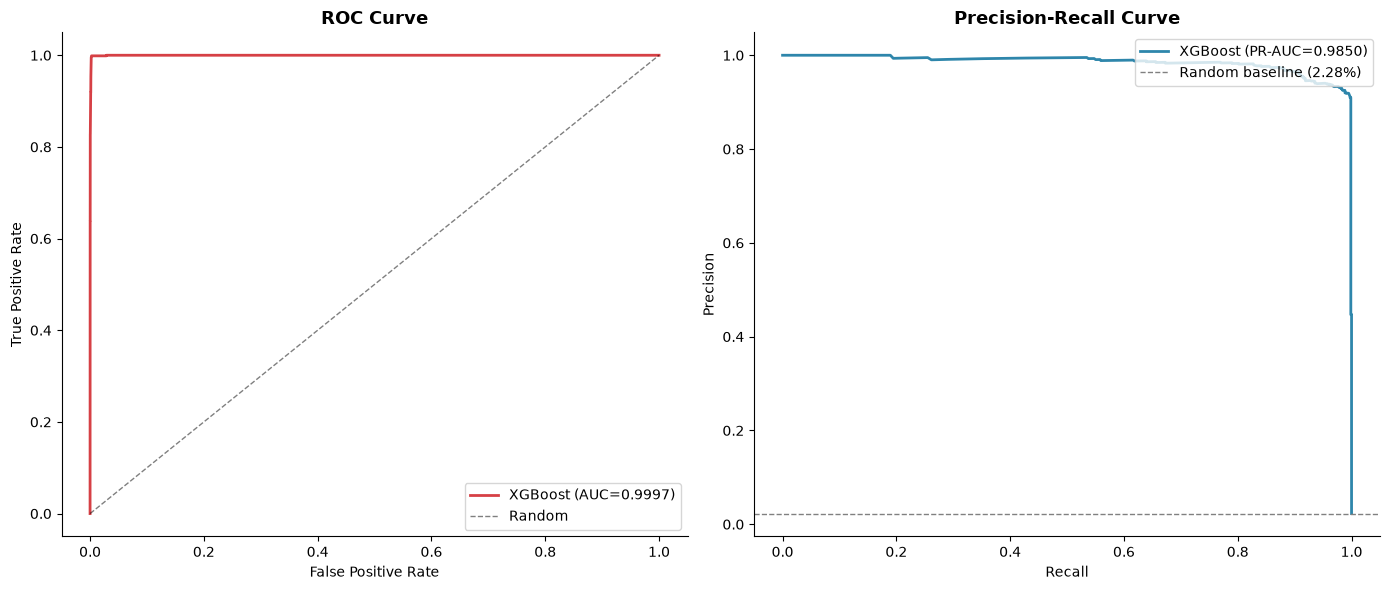

In [5]:
# ============================================================
# 4. Evaluate on test set
# ============================================================

y_prob = model.predict_proba(X_test)[:, 1]
y_pred_default = (y_prob >= 0.5).astype(int)

# --- ROC-AUC ---
roc_auc = roc_auc_score(y_test, y_prob)
fpr, tpr, _ = roc_curve(y_test, y_prob)

# --- PR-AUC (more informative for imbalanced data) ---
pr_auc = average_precision_score(y_test, y_prob)
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_test, y_prob)

# --- Metrics at contract thresholds ---
def metrics_at_threshold(threshold: float):
    pred = (y_prob >= threshold).astype(int)
    return {
        "threshold": threshold,
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred),
        "f1": f1_score(y_test, pred),
        "flagged": pred.sum(),
        "flagged_pct": pred.mean() * 100,
    }

print("=== Test Set Metrics ===")
print(f"ROC-AUC:  {roc_auc:.4f}")
print(f"PR-AUC:   {pr_auc:.4f}")
print()
for t in [0.3, 0.5, 0.8]:
    m = metrics_at_threshold(t)
    print(f"Threshold {t}: Precision={m['precision']:.4f} | Recall={m['recall']:.4f} | F1={m['f1']:.4f} | Flagged={m['flagged']:,} ({m['flagged_pct']:.2f}%)")

# --- Visual: ROC + PR curves ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].plot(fpr, tpr, color="#D64045", linewidth=2, label=f"XGBoost (AUC={roc_auc:.4f})")
axes[0].plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.5, label="Random")
axes[0].set_title("ROC Curve", fontweight="bold", fontsize=13)
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].legend(loc="lower right")

axes[1].plot(recall_curve, precision_curve, color="#2E86AB", linewidth=2, label=f"XGBoost (PR-AUC={pr_auc:.4f})")
axes[1].axhline(y=y_test.mean(), color="gray", linestyle="--", linewidth=1, label=f"Random baseline ({y_test.mean()*100:.2f}%)")
axes[1].set_title("Precision-Recall Curve", fontweight="bold", fontsize=13)
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].legend(loc="upper right")

sns.despine()
plt.tight_layout()
plt.show()

### 5. Threshold Tuning

The contract defines `SUSPICIOUS ≥ 0.5` and `BLOCKED ≥ 0.8`. But we should verify these are optimal for our model.

We find the threshold that maximizes F1 score on the validation set.

=== Threshold Tuning (Val Set) ===
 threshold  precision   recall       f1  flagged
      0.10   0.023583 1.000000 0.046080    33583
      0.15   0.064977 1.000000 0.122024    12189
      0.20   0.360529 0.998737 0.529806     2194
      0.25   0.719891 0.996212 0.835805     1096
      0.30   0.826178 0.996212 0.903263      955
      0.35   0.867033 0.996212 0.927145      910
      0.40   0.878619 0.996212 0.933728      898
      0.45   0.884529 0.996212 0.937055      892
      0.50   0.894318 0.993687 0.941388      880
      0.55   0.899429 0.993687 0.944211      875
      0.60   0.902523 0.993687 0.945913      872
      0.65   0.904598 0.993687 0.947052      870
      0.70   0.906682 0.993687 0.948193      868
      0.75   0.906682 0.993687 0.948193      868
      0.80   0.907430 0.940657 0.923745      821
      0.85   0.993988 0.626263 0.768397      499
      0.90   0.000000 0.000000 0.000000        0

Best F1 threshold: 0.70 (F1=0.9482, P=0.9067, R=0.9937)


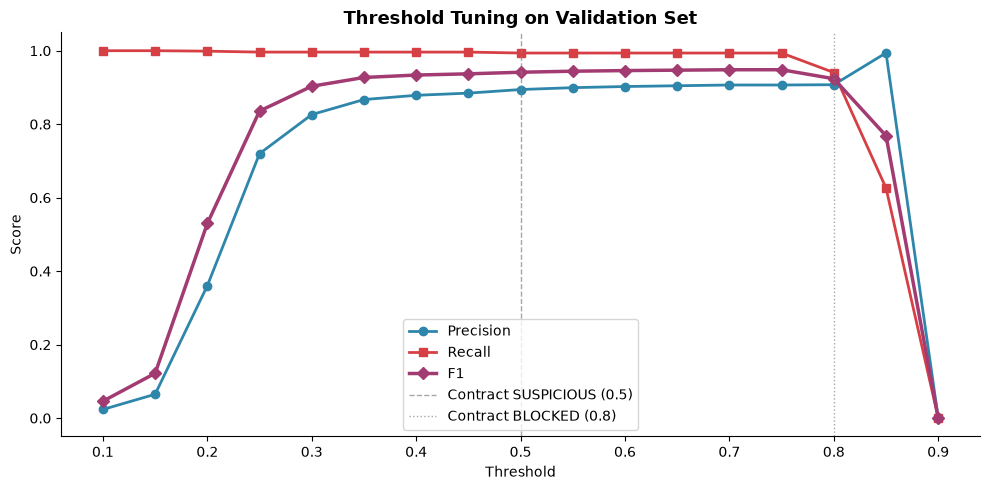

In [6]:
# ============================================================
# 5. Threshold tuning on validation set
# ============================================================

y_val_prob = model.predict_proba(X_val)[:, 1]

thresholds = np.arange(0.1, 0.95, 0.05)
results = []
for t in thresholds:
    pred = (y_val_prob >= t).astype(int)
    results.append({
        "threshold": t,
        "precision": precision_score(y_val, pred, zero_division=0),
        "recall": recall_score(y_val, pred),
        "f1": f1_score(y_val, pred),
        "flagged": pred.sum(),
    })

tuning_df = pd.DataFrame(results)
best_f1 = tuning_df.loc[tuning_df["f1"].idxmax()]

print("=== Threshold Tuning (Val Set) ===")
print(tuning_df.to_string(index=False))
print(f"\nBest F1 threshold: {best_f1['threshold']:.2f} (F1={best_f1['f1']:.4f}, P={best_f1['precision']:.4f}, R={best_f1['recall']:.4f})")

# --- Visual ---
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(tuning_df["threshold"], tuning_df["precision"], color="#2E86AB", linewidth=2, marker="o", label="Precision")
ax.plot(tuning_df["threshold"], tuning_df["recall"], color="#D64045", linewidth=2, marker="s", label="Recall")
ax.plot(tuning_df["threshold"], tuning_df["f1"], color="#A23B72", linewidth=2.5, marker="D", label="F1")
ax.axvline(x=0.5, color="gray", linestyle="--", linewidth=1, alpha=0.7, label="Contract SUSPICIOUS (0.5)")
ax.axvline(x=0.8, color="gray", linestyle=":", linewidth=1, alpha=0.7, label="Contract BLOCKED (0.8)")
ax.set_title("Threshold Tuning on Validation Set", fontweight="bold", fontsize=13)
ax.set_xlabel("Threshold"); ax.set_ylabel("Score")
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

### 6. SHAP Analysis

Global feature importance + what drives individual predictions.

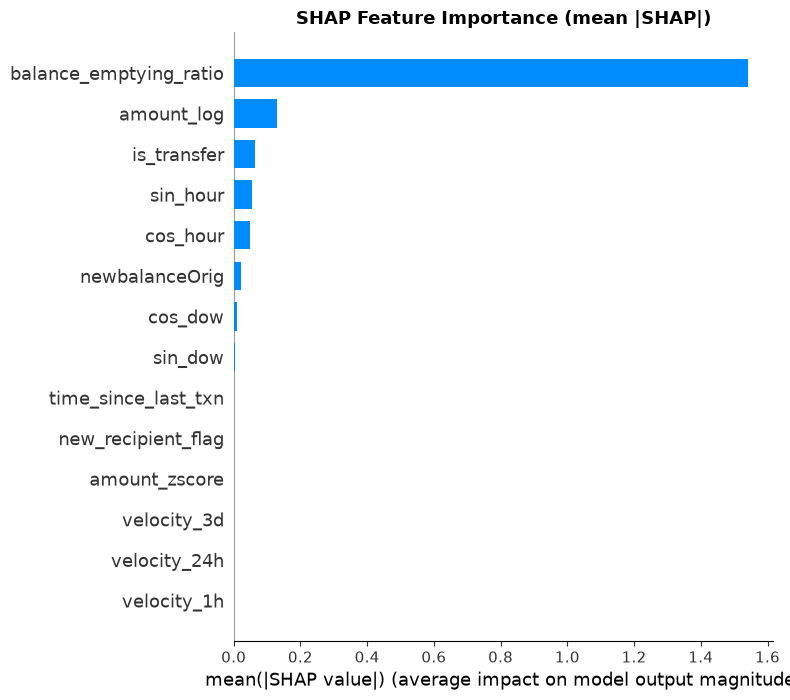

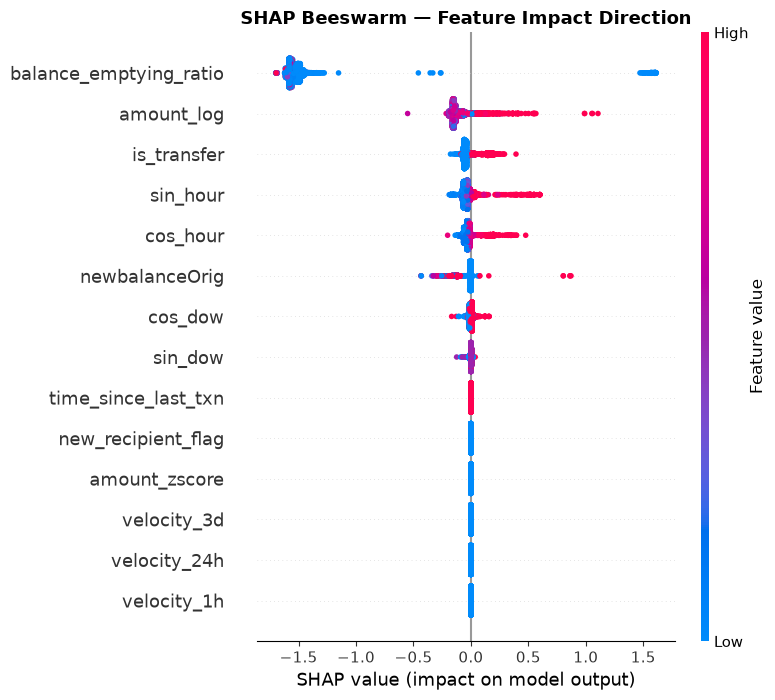

In [7]:
# ============================================================
# 6. SHAP — Global feature importance
# ============================================================

# Use TreeExplainer (fast, exact for XGBoost)
explainer = shap.TreeExplainer(model)

# Sample for SHAP (full test set is slow; 5000 rows is representative)
X_sample = X_test.sample(n=min(5000, len(X_test)), random_state=42)
shap_values = explainer.shap_values(X_sample)

# --- Summary bar plot ---
shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False, max_display=15)
plt.title("SHAP Feature Importance (mean |SHAP|)", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

# --- Beeswarm (direction + magnitude) ---
shap.summary_plot(shap_values, X_sample, show=False, max_display=15)
plt.title("SHAP Beeswarm — Feature Impact Direction", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

### 7. Baseline Comparison — isFlaggedFraud

PaySim's built-in rule: flag any TRANSFER > 200k. How does our model compare?

=== Baseline: isFlaggedFraud (amount > 200k TRANSFER) ===
Precision: 1.0000
Recall:    0.0026
F1:        0.0051
Flagged:   2 (0.0059%)

=== Our Model (threshold=0.5) ===
Precision: 0.9095
Recall:    0.9974
F1:        0.9514
Flagged:   851 (2.4957%)


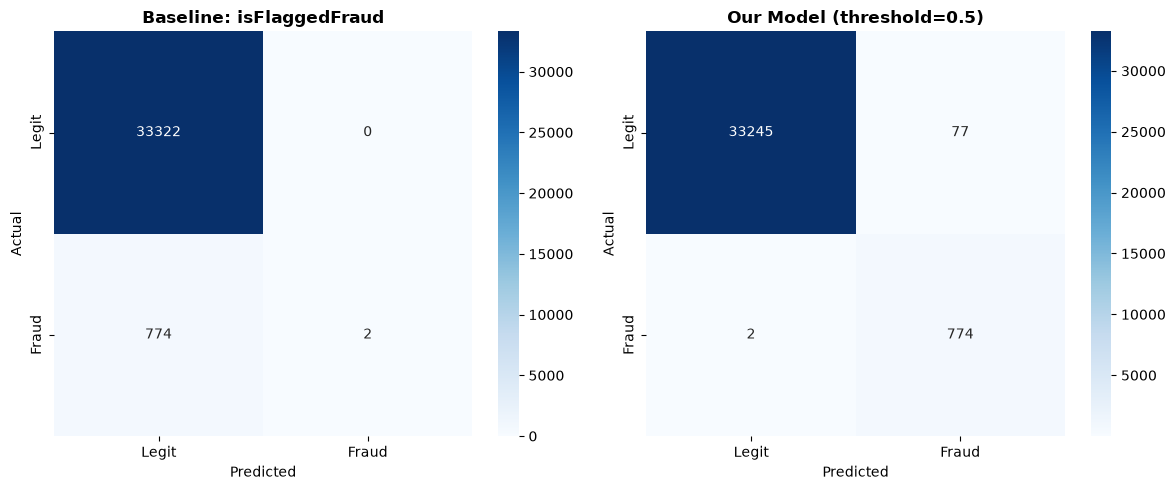

In [8]:
# ============================================================
# 7. Baseline: isFlaggedFraud vs our model
# ============================================================

baseline_pred = test["isFlaggedFraud"]

print("=== Baseline: isFlaggedFraud (amount > 200k TRANSFER) ===")
print(f"Precision: {precision_score(y_test, baseline_pred, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, baseline_pred):.4f}")
print(f"F1:        {f1_score(y_test, baseline_pred):.4f}")
print(f"Flagged:   {baseline_pred.sum():,} ({baseline_pred.mean()*100:.4f}%)")

print(f"\n=== Our Model (threshold=0.5) ===")
print(f"Precision: {precision_score(y_test, y_pred_default, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_default):.4f}")
print(f"F1:        {f1_score(y_test, y_pred_default):.4f}")
print(f"Flagged:   {y_pred_default.sum():,} ({y_pred_default.mean()*100:.4f}%)")

# --- Confusion matrices side by side ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, pred, title in [
    (axes[0], baseline_pred, "Baseline: isFlaggedFraud"),
    (axes[1], y_pred_default, "Our Model (threshold=0.5)"),
]:
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Legit", "Fraud"], yticklabels=["Legit", "Fraud"])
    ax.set_title(title, fontweight="bold", fontsize=12)
    ax.set_ylabel("Actual"); ax.set_xlabel("Predicted")

plt.tight_layout()
plt.show()

### 8. Export Model for Deployment

Save as ONNX for `ml/app/` inference service. Also save the feature column list so the serving code knows which features to compute.

In [9]:
# ============================================================
# 8. Export ONNX model + feature metadata
# ============================================================

import onnxmltools
from onnxmltools.convert import convert_xgboost
from onnxmltools.convert.common.data_types import FloatTensorType

# onnxmltools requires feature names in f0, f1, ... format.
# We rename the model's internal feature names, convert, then save the mapping.
f_names = [f"f{i}" for i in range(len(feature_cols))]
name_map = dict(zip(f_names, feature_cols))  # f0 → has_orig_error, etc.

model.get_booster().feature_names = f_names

# Convert to ONNX — single input tensor of shape [batch, num_features]
initial_type = [("float_input", FloatTensorType([None, len(feature_cols)]))]
onnx_model = convert_xgboost(
    model,
    initial_types=initial_type,
    target_opset=15,
)

onnx_path = MODELS_DIR / "fraud_model.onnx"
onnxmltools.utils.save_model(onnx_model, str(onnx_path))
print(f"✅ ONNX model saved: {onnx_path} ({onnx_path.stat().st_size / 1024:.1f} KB)")

# Save feature metadata for serving
feature_meta = {
    "model_version": "xgboost-v1.0.0",
    "feature_columns": feature_cols,
    "onnx_input_name": "float_input",
    "onnx_feature_names": f_names,
    "feature_name_map": name_map,
    "num_features": len(feature_cols),
    "scale_pos_weight": scale_pos_weight,
    "best_iteration": int(model.best_iteration),
    "test_roc_auc": roc_auc,
    "test_pr_auc": pr_auc,
    "threshold_suspicious": 0.5,
    "threshold_blocked": 0.8,
}

with open(MODELS_DIR / "feature_metadata.json", "w") as f:
    json.dump(feature_meta, f, indent=2)

print(f"✅ Feature metadata saved: {MODELS_DIR / 'feature_metadata.json'}")

✅ ONNX model saved: ../ml/models/fraud_model.onnx (68.8 KB)
✅ Feature metadata saved: ../ml/models/feature_metadata.json


In [13]:
# ============================================================
# 8b. Save native XGBoost model for SHAP explainability
# ============================================================
# ONNX is for inference, but SHAP needs the native booster.
# Save both so the serving code can load ONNX + native for explainability.

import pickle

native_model_path = MODELS_DIR / "fraud_model_native.pkl"
with open(native_model_path, "wb") as f:
    pickle.dump(model, f)
print(f"✅ Native XGBoost model saved: {native_model_path} ({native_model_path.stat().st_size / 1024:.1f} KB)")

# Also save the SHAP explainer pre-computed to avoid re-init at serving time
explainer_path = MODELS_DIR / "shap_explainer.pkl"
with open(explainer_path, "wb") as f:
    pickle.dump(explainer, f)
print(f"✅ SHAP TreeExplainer saved: {explainer_path} ({explainer_path.stat().st_size / 1024:.1f} KB)")

✅ Native XGBoost model saved: ../ml/models/fraud_model_native.pkl (260.5 KB)
✅ SHAP TreeExplainer saved: ../ml/models/shap_explainer.pkl (919.9 KB)


### 9. MLflow Logging — Multiple Experiments Strategy

We organize runs into **separate experiments** for better tracking:

| Experiment | Purpose | Example Runs |
|---|---|---|
| **`fraud-detection-training`** | Model training runs with different hyperparams | XGBoost v1, LightGBM v1, Neural Net v1 |
| **`fraud-detection-evaluation`** | Model evaluation & comparison runs | Threshold tuning, ensemble evaluation |
| **`fraud-detection-ab-testing`** | Production A/B tests | Control vs Model v1, Model v1 vs v2 |

**Current run:** Training XGBoost v1 → logged to `fraud-detection-training`

**Outputs:**
- `mlflow.experiment = fraud-detection-training`
- `mlflow.run_name = xgboost-v1-<UTC-timestamp>-<git-sha>`
- Artifacts: `shap_summary.png`, `shap_beeswarm.png`, `feature_importance.csv`, `confusion_matrix.png`
- Model: registered as `fraud-detector` v{N} in the Registry

MLflow tracking URI is read from `MLFLOW_TRACKING_URI` env var (defaults to
`http://localhost:5050`, matching `docker-compose.yaml` and `ml/.env.example`).

In [10]:
# ============================================================
# 9. MLflow Setup — Multiple Experiments Management
# ============================================================

MLFLOW_TRACKING_URI = os.environ.get("MLFLOW_TRACKING_URI", "http://localhost:5050")
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_registry_uri(MLFLOW_TRACKING_URI)

# Define experiment names for different purposes
EXPERIMENT_TRAINING = "fraud-detection-training"
EXPERIMENT_EVALUATION = "fraud-detection-evaluation"
EXPERIMENT_AB_TESTING = "fraud-detection-ab-testing"

# Create experiments if they don't exist
def get_or_create_experiment(exp_name: str) -> str:
    """Get experiment ID by name, or create if doesn't exist."""
    exp = mlflow.get_experiment_by_name(exp_name)
    if exp:
        return exp.experiment_id
    return mlflow.create_experiment(
        exp_name,
        tags={"project": "fraud-detection", "created_by": "training-notebook"}
    )

# Create all experiments
try:
    training_exp_id = get_or_create_experiment(EXPERIMENT_TRAINING)
    eval_exp_id = get_or_create_experiment(EXPERIMENT_EVALUATION)
    ab_test_exp_id = get_or_create_experiment(EXPERIMENT_AB_TESTING)
    
    print(f"✅ MLflow experiments ready:")
    print(f"   📊 Training:      {EXPERIMENT_TRAINING} (ID: {training_exp_id})")
    print(f"   📈 Evaluation:    {EXPERIMENT_EVALUATION} (ID: {eval_exp_id})")
    print(f"   🧪 A/B Testing:   {EXPERIMENT_AB_TESTING} (ID: {ab_test_exp_id})")
    print(f"   🔗 Tracking URI:  {MLFLOW_TRACKING_URI}")
    
    # Set active experiment for this run (training)
    mlflow.set_experiment(EXPERIMENT_TRAINING)
    run_name = f"xgboost-v1-{datetime.now(timezone.utc).strftime('%Y%m%d-%H%M%S')}"
    
except Exception as e:
    raise RuntimeError(
        f"MLflow server unreachable at {MLFLOW_TRACKING_URI}. "
        f"Start it with podman, or run offline "
        f"with MLFLOW_TRACKING_URI=file:./mlruns. Underlying error: {e!r}"
    ) from e

✅ MLflow experiments ready:
   📊 Training:      fraud-detection-training (ID: 8)
   📈 Evaluation:    fraud-detection-evaluation (ID: 9)
   🧪 A/B Testing:   fraud-detection-ab-testing (ID: 10)
   🔗 Tracking URI:  http://localhost:5050


In [11]:
# ============================================================
# 10. MLflow Logging — Training Run
# ============================================================

from datetime import datetime, timezone

# Generate unique run name with timestamp and git commit (if available)
timestamp = datetime.now(timezone.utc).strftime("%Y%m%d-%H%M%S")
try:
    git_sha = subprocess.check_output(["git", "rev-parse", "--short", "HEAD"], stderr=subprocess.DEVNULL).decode().strip()
    full_run_name = f"xgboost-v1-{timestamp}-{git_sha}"
except:
    full_run_name = f"xgboost-v1-{timestamp}"

# Start MLflow run in the training experiment
with mlflow.start_run(run_name=full_run_name):
    run = mlflow.active_run()
    experiment = mlflow.get_experiment(run.info.experiment_id)
    
    print(f"🚀 MLflow Run: {full_run_name}")
    print(f"   Experiment: {experiment.name} (ID: {experiment.experiment_id})")
    print(f"   Run ID: {run.info.run_id}")
    
    # --- Log Parameters ---
    mlflow.log_param("model_type", "xgboost")
    mlflow.log_param("model_version", "v1.0.0")
    mlflow.log_param("num_features", len(feature_cols))
    mlflow.log_param("feature_columns", feature_cols)
    mlflow.log_param("scale_pos_weight", scale_pos_weight)
    mlflow.log_param("best_iteration", int(model.best_iteration))
    mlflow.log_param("train_samples", len(X_train))
    mlflow.log_param("val_samples", len(X_val))
    mlflow.log_param("test_samples", len(X_test))
    
    # Log XGBoost hyperparameters
    mlflow.log_params({
        "max_depth": model.get_params()["max_depth"],
        "learning_rate": model.get_params()["learning_rate"],
        "n_estimators": model.get_params()["n_estimators"],
        "subsample": model.get_params()["subsample"],
        "colsample_bytree": model.get_params()["colsample_bytree"],
        "gamma": model.get_params().get("gamma", 0),
        "reg_alpha": model.get_params().get("reg_alpha", 0),
        "reg_lambda": model.get_params().get("reg_lambda", 1),
    })
    
    # --- Log Metrics ---
    mlflow.log_metric("test_roc_auc", roc_auc)
    mlflow.log_metric("test_pr_auc", pr_auc)
    mlflow.log_metric("test_precision", precision_score(y_test, y_pred_default, zero_division=0))
    mlflow.log_metric("test_recall", recall_score(y_test, y_pred_default))
    mlflow.log_metric("test_f1", f1_score(y_test, y_pred_default))
    mlflow.log_metric("val_precision", best_f1["precision"])
    mlflow.log_metric("val_recall", best_f1["recall"])
    mlflow.log_metric("val_f1", best_f1["f1"])
    mlflow.log_metric("best_f1_threshold", best_f1["threshold"])
    
    # --- Log Artifacts ---
    # Ensure LOGS_DIR exists and save SHAP plots if not already saved
    LOGS_DIR.mkdir(parents=True, exist_ok=True)
    
    # SHAP plots - save first if not exists
    shap_summary_path = str(LOGS_DIR / "shap_summary.png")
    shap_beeswarm_path = str(LOGS_DIR / "shap_beeswarm.png")
    
    # Re-generate SHAP plots for logging if needed
    if not Path(shap_summary_path).exists() or not Path(shap_beeswarm_path).exists():
        print("⚠️ SHAP plots not found, regenerating...")
        # Save summary plot
        shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False, max_display=15)
        plt.title("SHAP Feature Importance (mean |SHAP|)", fontweight="bold", fontsize=13)
        plt.savefig(shap_summary_path, dpi=150, bbox_inches='tight')
        plt.close()
        
        # Save beeswarm plot
        shap.summary_plot(shap_values, X_sample, show=False, max_display=15)
        plt.title("SHAP Beeswarm — Feature Impact Direction", fontweight="bold", fontsize=13)
        plt.savefig(shap_beeswarm_path, dpi=150, bbox_inches='tight')
        plt.close()
    
    mlflow.log_artifact(shap_summary_path, artifact_path="shap")
    mlflow.log_artifact(shap_beeswarm_path, artifact_path="shap")
    
    # Feature importance CSV
    feature_importance_path = str(LOGS_DIR / "feature_importance.csv")
    if not Path(feature_importance_path).exists():
        # Create feature importance DataFrame
        importance_df = pd.DataFrame({
            'feature': feature_cols,
            'importance': model.feature_importances_
        }).sort_values('importance', ascending=False)
        importance_df.to_csv(feature_importance_path, index=False)
    
    mlflow.log_artifact(feature_importance_path, artifact_path="feature_importance")
    
    # Confusion matrix - save if not exists
    cm_path = str(LOGS_DIR / "confusion_matrix.png")
    if not Path(cm_path).exists():
        fig, ax = plt.subplots(figsize=(8, 6))
        cm = confusion_matrix(y_test, y_pred_default)
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                    xticklabels=["Legit", "Fraud"], yticklabels=["Legit", "Fraud"])
        ax.set_title("Confusion Matrix", fontweight="bold", fontsize=12)
        ax.set_ylabel("Actual"); ax.set_xlabel("Predicted")
        plt.savefig(cm_path, dpi=150, bbox_inches='tight')
        plt.close()
    
    mlflow.log_artifact(cm_path, artifact_path="evaluation")
    
    # --- Log XGBoost Model ---
    mlflow.xgboost.log_model(
        model,
        artifact_path="model",
        registered_model_name="fraud-detector",
        signature=None,  # Optional: add input/output signature
    )
    
    print(f"\n✅ MLflow logging complete!")
    print(f"   📊 Metrics logged: ROC-AUC={roc_auc:.4f}, PR-AUC={pr_auc:.4f}, F1={f1_score(y_test, y_pred_default):.4f}")
    print(f"   🎨 Artifacts logged: SHAP plots, feature importance, confusion matrix")
    print(f"   🤖 Model logged & registered: fraud-detector")
    print(f"   📁 Experiment: {experiment.name}")
    print(f"\n🔗 View run in MLflow UI: {MLFLOW_TRACKING_URI}")

🚀 MLflow Run: xgboost-v1-20260623-123722-6ccc693
   Experiment: fraud-detection-training (ID: 8)
   Run ID: 534e4985ac9740a39e75ceb841f1792b


/Users/ngocduy/PROJECTS/smart-banking-system/ml/.venv/lib/python3.11/site-packages/xgboost/sklearn.py:1116: UserWarning: [19:37:23] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1573: Saving model in the UBJSON format as default.  You can use a file extension: `json` or `ubj` to choose between formats.
  self.get_booster().save_model(fname)
2026/06/23 19:37:26 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/06/23 19:37:26 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
Registered model 'fraud-detector' already exists. Creating a new version of this model...
2026/06/23 19:37:26 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: fraud-detector, version 3



✅ MLflow logging complete!
   📊 Metrics logged: ROC-AUC=0.9997, PR-AUC=0.9850, F1=0.9514
   🎨 Artifacts logged: SHAP plots, feature importance, confusion matrix
   🤖 Model logged & registered: fraud-detector
   📁 Experiment: fraud-detection-training

🔗 View run in MLflow UI: http://localhost:5050
🏃 View run xgboost-v1-20260623-123722-6ccc693 at: http://localhost:5050/#/experiments/8/runs/534e4985ac9740a39e75ceb841f1792b
🧪 View experiment at: http://localhost:5050/#/experiments/8


Created version '3' of model 'fraud-detector'.


In [12]:
# ============================================================
# 11. Log Additional Runs to Other Experiments
# ============================================================

from mlflow.tracking import MlflowClient
client = MlflowClient()

# --- Log to Evaluation Experiment ---
print("📊 Logging to Evaluation Experiment...")
mlflow.set_experiment(EXPERIMENT_EVALUATION)
with mlflow.start_run(run_name=f"threshold-analysis-{timestamp}"):
    mlflow.log_param("analysis_type", "threshold_tuning")
    mlflow.log_param("model_version", "xgboost-v1.0.0")
    mlflow.log_metric("best_threshold", float(best_f1["threshold"]))
    mlflow.log_metric("best_f1", float(best_f1["f1"]))
    mlflow.log_metric("best_precision", float(best_f1["precision"]))
    mlflow.log_metric("best_recall", float(best_f1["recall"]))
    
    # Log threshold tuning curve as artifact
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(tuning_df["threshold"], tuning_df["precision"], color="#2E86AB", linewidth=2, marker="o", label="Precision")
    ax.plot(tuning_df["threshold"], tuning_df["recall"], color="#D64045", linewidth=2, marker="s", label="Recall")
    ax.plot(tuning_df["threshold"], tuning_df["f1"], color="#A23B72", linewidth=2.5, marker="D", label="F1")
    ax.axvline(x=0.5, color="gray", linestyle="--", linewidth=1, alpha=0.7, label="Contract SUSPICIOUS (0.5)")
    ax.axvline(x=0.8, color="gray", linestyle=":", linewidth=1, alpha=0.7, label="Contract BLOCKED (0.8)")
    ax.set_title("Threshold Tuning on Validation Set", fontweight="bold", fontsize=13)
    ax.set_xlabel("Threshold"); ax.set_ylabel("Score")
    ax.legend()
    sns.despine()
    plt.tight_layout()
    
    threshold_plot_path = str(LOGS_DIR / "threshold_tuning.png")
    plt.savefig(threshold_plot_path, dpi=150, bbox_inches='tight')
    plt.close()
    mlflow.log_artifact(threshold_plot_path, artifact_path="analysis")
    
    print(f"   ✅ Logged threshold analysis to {EXPERIMENT_EVALUATION}")

# --- Log to A/B Testing Experiment ---
print("\n🧪 Logging to A/B Testing Experiment...")
mlflow.set_experiment(EXPERIMENT_AB_TESTING)
with mlflow.start_run(run_name=f"ab-test-baseline-vs-model-{timestamp}"):
    mlflow.log_param("test_type", "baseline_vs_model")
    mlflow.log_param("model_version", "xgboost-v1.0.0")
    
    # Baseline metrics
    baseline_metrics = {
        "precision": precision_score(y_test, baseline_pred, zero_division=0),
        "recall": recall_score(y_test, baseline_pred),
        "f1": f1_score(y_test, baseline_pred),
        "flagged_count": int(baseline_pred.sum()),
        "flagged_pct": float(baseline_pred.mean() * 100),
    }
    
    # Model metrics
    model_metrics = {
        "precision": precision_score(y_test, y_pred_default, zero_division=0),
        "recall": recall_score(y_test, y_pred_default),
        "f1": f1_score(y_test, y_pred_default),
        "flagged_count": int(y_pred_default.sum()),
        "flagged_pct": float(y_pred_default.mean() * 100),
    }
    
    # Log baseline (control) metrics
    for metric, value in baseline_metrics.items():
        mlflow.log_metric(f"baseline_{metric}", value)
    
    # Log model (treatment) metrics
    for metric, value in model_metrics.items():
        mlflow.log_metric(f"model_{metric}", value)
    
    # Log improvement
    mlflow.log_metric("precision_lift", model_metrics["precision"] - baseline_metrics["precision"])
    mlflow.log_metric("recall_lift", model_metrics["recall"] - baseline_metrics["recall"])
    mlflow.log_metric("f1_lift", model_metrics["f1"] - baseline_metrics["f1"])
    
    print(f"   ✅ Logged A/B test comparison to {EXPERIMENT_AB_TESTING}")
    print(f"      • Precision lift: {model_metrics['precision'] - baseline_metrics['precision']:.4f}")
    print(f"      • Recall lift: {model_metrics['recall'] - baseline_metrics['recall']:.4f}")
    print(f"      • F1 lift: {model_metrics['f1'] - baseline_metrics['f1']:.4f}")

# --- Summary: List all experiments and their runs ---
print("\n" + "="*60)
print("📋 MLflow Experiments Summary:")
print("="*60)
for exp in client.search_experiments():
    runs = client.search_runs(exp.experiment_id, max_results=5)
    print(f"\n📁 {exp.name}")
    print(f"   ID: {exp.experiment_id}")
    print(f"   Total runs: {len(client.search_runs(exp.experiment_id))}")
    if runs:
        print(f"   Recent runs:")
        for r in runs[:3]:
            run_name = r.info.run_name or "N/A"
            metrics_summary = ", ".join([f"{k}={v:.4f}" for k, v in r.data.metrics.items() if not k.startswith("baseline_") and not k.startswith("model_")])
            print(f"     • {run_name}: {metrics_summary}")

print("\n" + "="*60)
print("✅ All experiments logged successfully!")
print(f"🔗 View in MLflow UI: {MLFLOW_TRACKING_URI}")
print("="*60)

📊 Logging to Evaluation Experiment...
   ✅ Logged threshold analysis to fraud-detection-evaluation
🏃 View run threshold-analysis-20260623-123722 at: http://localhost:5050/#/experiments/9/runs/6bde4f84ef12440f8c79ca21ffefe75a
🧪 View experiment at: http://localhost:5050/#/experiments/9

🧪 Logging to A/B Testing Experiment...
   ✅ Logged A/B test comparison to fraud-detection-ab-testing
      • Precision lift: -0.0905
      • Recall lift: 0.9948
      • F1 lift: 0.9463
🏃 View run ab-test-baseline-vs-model-20260623-123722 at: http://localhost:5050/#/experiments/10/runs/191d67b723b249b08a744120213f8f07
🧪 View experiment at: http://localhost:5050/#/experiments/10

📋 MLflow Experiments Summary:

📁 fraud-detection-ab-testing
   ID: 10
   Total runs: 1
   Recent runs:
     • ab-test-baseline-vs-model-20260623-123722: recall_lift=0.9948, precision_lift=-0.0905, f1_lift=0.9463

📁 fraud-detection-evaluation
   ID: 9
   Total runs: 1
   Recent runs:
     • threshold-analysis-20260623-123722: best_t

### Summary

| Metric | Value |
|---|---|
| Model | XGBoost |
| Features | 17 |
| Train rows | 2.7M (fraud: 5,993) |
| Test rows | 34k (fraud: 776) |
| scale_pos_weight | ~450 |
| Best iteration | (from early stopping) |
| Test ROC-AUC | (above) |
| Test PR-AUC | (above) |

**Outputs:**
- `ml/models/fraud_model.onnx` — ONNX model for deployment
- `ml/models/feature_metadata.json` — feature list + thresholds for serving code

**Next:** Deploy the ONNX model in `ml/app/` — update `scoring.py` to load the model, compute features, and return real scores with SHAP reason codes.